# Testing Notebook

This notebook is formatted so that you can toggle cells by highlighting everything and then cmd + / (comment shortcut).

This way, comments stay as comments and the code toggles on and off.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from network import Network

data = np.load('mnist.npz')
x_train = data["x_train"] / 255 # NOTE normalizing the data here
y_train = data["y_train"]
x_test = data["x_test"] / 255
y_test = data["y_test"]

### Testing Descent Functionality

In [9]:
def test_accuracy(network, x_test=x_test, y_test=y_test, test_size=500):

    test_idxs = np.random.choice(len(x_test), test_size,replace=False)
    x_test = x_test[test_idxs]
    y_test = y_test[test_idxs]

    results = np.zeros_like(x_test)

    for i in range(len(x_test)):
        output = network.f_prop(x_test[i], output_only=True)
        
        prediction = np.argmax(output)
        true_val = y_test[i]
    
        if prediction == true_val:
            results[i] = 1

    accuracy = np.mean(results)
    # print(f'network accuracy: {accuracy * 100:.2f}%')
    return np.mean(results)

In [ ]:
ALPHA      = 0.9
MAX_STEPS  = 2000
BATCH_SIZE = 32

net2 = Network(shape=[784,128,64,10])
pre = test_accuracy(net2, x_test=x_test, y_test=y_test)
net2.descend_stoc(x_train=x_train,
             y_train=y_train,
             alpha=ALPHA,
             max_steps=MAX_STEPS,
             batch_size=BATCH_SIZE
             )
post = test_accuracy(net2, x_test=x_test, y_test=y_test)


print( '----------------DESCENT SUMMARY----------------')
print(f'alpha = {ALPHA}, max_steps = {MAX_STEPS}, batch_size={BATCH_SIZE}')
print(f'pre-descent:{pre*100:.2f}')
print(f'post-descent:{post*100:.2f}')

----------------DESCENT SUMMARY----------------
alpha = 0.9, max_steps = 2000, batch_size=32
pre-descent:14.80
post-descent:95.20


### Visualizing Improvement Rate

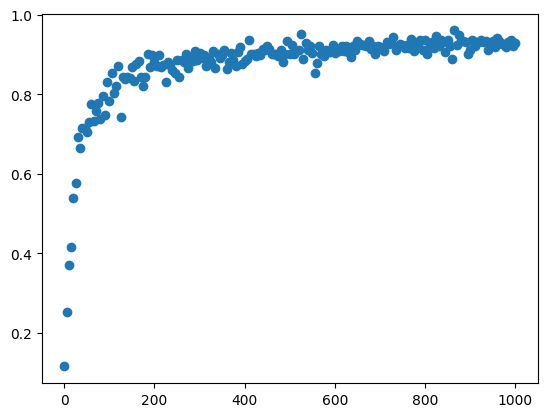

In [ ]:
TOTAL_STEPS = 1000
TEST_EVERY  = 5
ALPHA = 0.5
net2 = Network(shape=[784,128,64,10])

x = [i for i in range(0,TOTAL_STEPS+1, TEST_EVERY)] 
y = [test_accuracy(net2)]

for i in range(TEST_EVERY, TOTAL_STEPS+1, TEST_EVERY):
    net2.descend_stoc(x_train=x_train,y_train=y_train,alpha=ALPHA,max_steps=TEST_EVERY,batch_size=32)

    y.append(test_accuracy(net2))

plt.scatter(x, y)
plt.show()

### Standardizing The Module

Q: how do we standardize the x_train, y_train inputs  
Q: what do we do about the output one hot encoding (temp function right now in .get_descent method)  
Q: setting up epochs  

Major Question: Do we want things like epoch optimization to all be parts of the network class, or do have other parent classes/functions/etc. that use this simple network. Descent is already part of the class so I think it makes sense to do that.

### Pick the Best of 20

### Graphing Alpha, Batch Size, etc.